# Swiggy Customer Funnel, Retention & A/B Test Analysis
### Product Analyst Portfolio Project — Indian Market Edition

**Author:** Shekhar
**Datasets:**
- Swiggy Orders & Users (real transactional data, India, ~1 lakh users)
- Cookie Cats Mobile Game A/B Test (Tactile Entertainment, 90,189 players)

**Objective:** Analyze customer funnel, retention, and RFM segmentation on Swiggy data, and run a statistically rigorous A/B test analysis on Cookie Cats data to derive a product recommendation.


## 0. Setup — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'


---
# PART A — Swiggy: Funnel, Retention & RFM Analysis


## 1. Data Loading & Cleaning

In [2]:
orders = pd.read_excel('swiggy_orders.xlsx')
users = pd.read_excel('swiggy_users.xlsx')

print("Orders shape:", orders.shape)
print("Users shape:", users.shape)
orders.head()


Orders shape: (150281, 6)
Users shape: (100000, 6)


,order_date,sales_qty,sales_amount,currency,user_id,r_id
0,2017-10-10,100,41241,INR,49226,567335.0
1,2018-05-08,3,-1,INR,77359,531342.0
2,2018-04-06,1,875,INR,5321,158203.0
3,2018-04-11,1,583,INR,21343,187912.0
4,2018-06-18,6,7176,INR,75378,543530.0


In [3]:
# Data quality checks
print("Missing values in orders:\n", orders.isnull().sum())
print("\nDuplicate order rows:", orders.duplicated().sum())
print("Negative sales_amount rows:", (orders['sales_amount'] < 0).sum())
print("Zero sales_amount rows:", (orders['sales_amount'] == 0).sum())


Missing values in orders:
 order_date         0
sales_qty          0
sales_amount       0
currency           0
user_id            0
r_id            1617
dtype: int64

Duplicate order rows: 0
Negative sales_amount rows: 2
Zero sales_amount rows: 1609


In [4]:
# Clean: remove invalid negative amounts, flag zero-value (free/promo) orders
orders_clean = orders[orders['sales_amount'] >= 0].copy()
orders_clean['is_zero_value'] = orders_clean['sales_amount'] == 0
orders_clean['order_date'] = pd.to_datetime(orders_clean['order_date'])
orders_clean['order_year_month'] = orders_clean['order_date'].dt.to_period('M')

users.columns = users.columns.str.strip().str.lower().str.replace(' ', '_')

print(f"Cleaned orders shape: {orders_clean.shape}")
orders_clean.head()


Cleaned orders shape: (150279, 8)


,order_date,sales_qty,sales_amount,currency,user_id,r_id,is_zero_value,order_year_month
0,2017-10-10,100,41241,INR,49226,567335.0,False,2017-10
2,2018-04-06,1,875,INR,5321,158203.0,False,2018-04
3,2018-04-11,1,583,INR,21343,187912.0,False,2018-04
4,2018-06-18,6,7176,INR,75378,543530.0,False,2018-06
5,2017-11-20,59,500,INR,34323,158204.0,False,2017-11


In [5]:
# Merge orders with users (left join to retain zero-order users too)
master = users.merge(orders_clean, on='user_id', how='left')
print("Master dataset shape:", master.shape)
print("Users with >=1 order:", master[master['order_date'].notnull()]['user_id'].nunique())
print("Users with zero orders:", master[master['order_date'].isnull()]['user_id'].nunique())


Master dataset shape: (172350, 13)


Users with >=1 order: 77929
Users with zero orders: 22071


## 2. Customer Conversion Funnel

Since this is order-level (not clickstream) data, the funnel represents the **customer lifecycle**:

`Total Registered Users -> Ordered >=1 Time -> Repeat Customers (2+ Orders) -> Loyal Customers (Top 10% Spend)`


In [6]:
user_orders = orders_clean.groupby('user_id').agg(
    order_count=('sales_amount', 'count'),
    total_spend=('sales_amount', 'sum')
).reset_index()

total_users = users['user_id'].nunique()
ordered_users = user_orders['user_id'].nunique()
repeat_users = (user_orders['order_count'] >= 2).sum()
spend_threshold = user_orders['total_spend'].quantile(0.90)
loyal_users = (user_orders['total_spend'] >= spend_threshold).sum()

funnel = pd.DataFrame({
    'Stage': ['Total Registered Users', 'Ordered >=1 Time', 'Repeat Customers (2+ Orders)', 'Loyal Customers (Top 10% Spend)'],
    'Users': [total_users, ordered_users, repeat_users, loyal_users]
})
funnel['% of Total'] = (funnel['Users'] / total_users * 100).round(1)
funnel['% Conversion from Previous Stage'] = (funnel['Users'] / funnel['Users'].shift(1) * 100).round(1)
funnel


,Stage,Users,% of Total,% Conversion from Previous Stage
0,Total Registered Users,100000,100.0,NaN
1,Ordered >=1 Time,77929,77.9,77.9
2,Repeat Customers (2+ Orders),44472,44.5,57.1
3,Loyal Customers (Top 10% Spend),7793,7.8,17.5


In [7]:
top10_revenue = user_orders.nlargest(int(len(user_orders)*0.10), 'total_spend')['total_spend'].sum()
total_revenue = user_orders['total_spend'].sum()
print(f"Top 10% customers contribute {top10_revenue/total_revenue*100:.1f}% of total revenue")
print(f"Loyal customer spend threshold: >= {spend_threshold:,.0f} INR")


Top 10% customers contribute 69.4% of total revenue
Loyal customer spend threshold: >= 28,950 INR


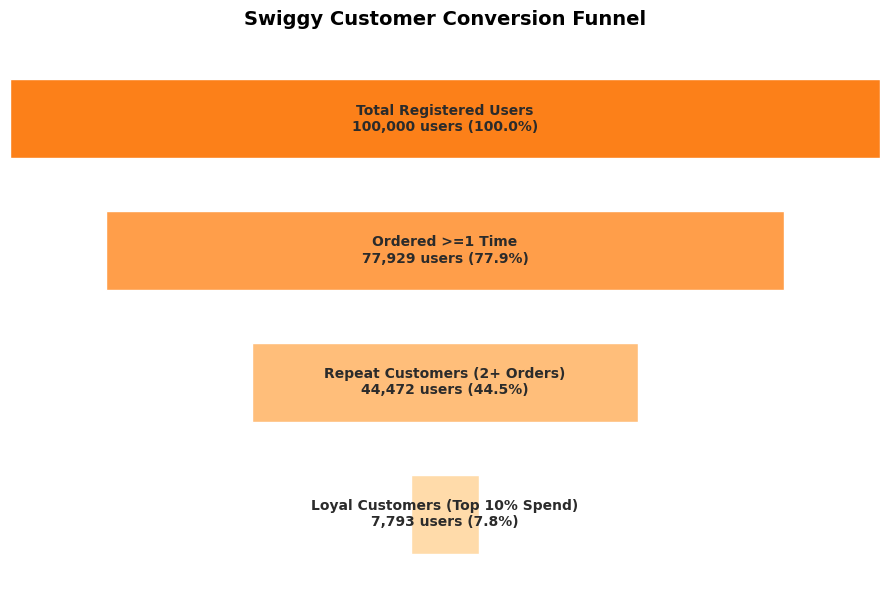

In [8]:
# Funnel visualization
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#FC8019', '#FF9E4A', '#FFBE7A', '#FFDBAA']
stages = funnel['Stage']
values = funnel['Users']
max_val = values.max()

for i, (stage, val) in enumerate(zip(stages, values)):
    width = val / max_val
    left = (1 - width) / 2
    ax.barh(len(stages)-1-i, width, left=left, height=0.6, color=colors[i], edgecolor='white')
    ax.text(0.5, len(stages)-1-i, f"{stage}\n{val:,} users ({funnel['% of Total'][i]}%)",
            ha='center', va='center', fontsize=10, fontweight='bold', color='#2b2b2b')

ax.set_xlim(0, 1); ax.set_ylim(-0.5, len(stages)-0.5); ax.axis('off')
ax.set_title('Swiggy Customer Conversion Funnel', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('funnel_chart.png', dpi=150, bbox_inches='tight')
plt.show()


**Key Insights:**
- 22.1% of registered users never place a single order — the biggest drop-off point
- Only 57.1% of first-time buyers order again (retention gap)
- Top 10% of customers contribute ~69% of total revenue (classic Pareto pattern)


## 3. Cohort Retention Analysis

Grouping users by the month of their **first order** (acquisition cohort), then tracking what % of each cohort re-orders in subsequent months.


In [9]:
cohort_month = orders_clean.groupby('user_id')['order_year_month'].min().reset_index()
cohort_month.columns = ['user_id', 'cohort_month']

orders_c = orders_clean.merge(cohort_month, on='user_id')
orders_c['period_number'] = (orders_c['order_year_month'] - orders_c['cohort_month']).apply(lambda x: x.n)

cohort_data = orders_c.groupby(['cohort_month', 'period_number'])['user_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='period_number', values='user_id')
cohort_sizes = cohort_pivot.iloc[:, 0]
retention_pct = cohort_pivot.divide(cohort_sizes, axis=0) * 100

retention_pct.iloc[:10, :8].round(1)


period_number,0,1,2,3,4,5,6,7
cohort_month,,,,,,,,
2017-10,100.0,4.4,4.2,4.6,4.7,5.0,5.0,5.2
2017-11,100.0,4.7,5.1,5.0,4.6,4.9,5.1,5.5
2017-12,100.0,4.8,4.6,5.3,4.5,5.1,5.3,5.7
2018-01,100.0,4.8,5.0,5.0,5.5,5.5,5.4,5.2
2018-02,100.0,5.4,5.2,5.0,5.7,5.2,5.3,4.8
2018-03,100.0,5.2,5.6,4.9,5.2,5.3,4.8,4.8
2018-04,100.0,5.0,5.0,5.3,5.0,4.7,5.5,4.8
2018-05,100.0,5.2,5.2,5.1,5.3,5.6,4.4,3.7
2018-06,100.0,5.2,5.3,4.4,5.2,4.5,4.6,4.6


In [10]:
avg_m1_retention = retention_pct[1].mean()
print(f"Average Month-1 Retention across all cohorts: {avg_m1_retention:.1f}%")


Average Month-1 Retention across all cohorts: 4.4%


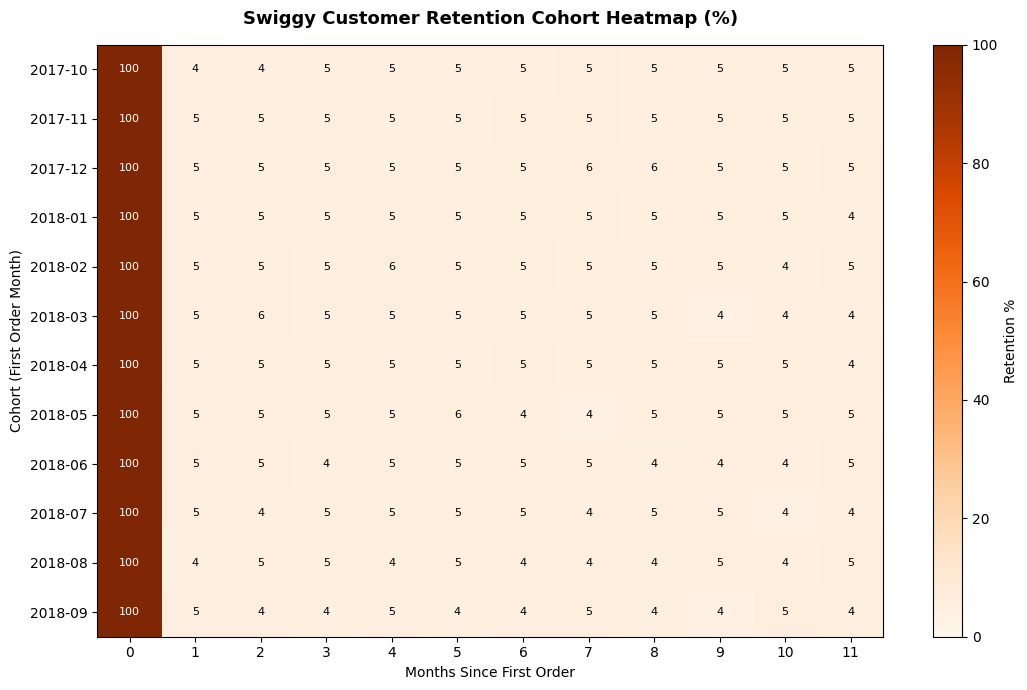

In [11]:
# Cohort heatmap
data = retention_pct.iloc[:12, :12]
fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(data.values, cmap='Oranges', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(data.shape[1])); ax.set_xticklabels(data.columns)
ax.set_yticks(range(data.shape[0])); ax.set_yticklabels(data.index)
ax.set_xlabel('Months Since First Order'); ax.set_ylabel('Cohort (First Order Month)')
ax.set_title('Swiggy Customer Retention Cohort Heatmap (%)', fontsize=13, fontweight='bold', pad=15)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data.values[i, j]
        if not np.isnan(val):
            color = 'white' if val > 50 else 'black'
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', color=color, fontsize=8)

plt.colorbar(im, label='Retention %')
plt.tight_layout()
plt.savefig('cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


**Key Insight:** Month-1 retention averages only ~4.4% across cohorts — most users in this dataset are one-time or infrequent purchasers, highlighting a major opportunity for re-engagement campaigns targeting recently acquired customers.


## 4. RFM Segmentation

Segmenting customers by **Recency, Frequency, Monetary** value into actionable groups.


In [12]:
snapshot_date = orders_clean['order_date'].max() + pd.Timedelta(days=1)

rfm = orders_clean.groupby('user_id').agg(
    recency=('order_date', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_date', 'count'),
    monetary=('sales_amount', 'sum')
).reset_index()

rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_sum'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

def segment(row):
    r, f = row['R_score'], row['F_score']
    if r >= 4 and f >= 4: return 'Champions'
    elif r >= 3 and f >= 3: return 'Loyal Customers'
    elif r >= 4 and f <= 2: return 'New/Promising'
    elif r <= 2 and f >= 4: return 'At Risk'
    elif r <= 2 and f <= 2: return 'Lost'
    else: return 'Need Attention'

rfm['Segment'] = rfm.apply(segment, axis=1)
rfm.head()


,user_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_sum,Segment
0,1,591,2,1672,2,3,3,8,Need Attention
1,2,694,3,4061,1,4,4,9,At Risk
2,3,409,1,21542,3,1,5,9,Need Attention
3,4,507,1,102,2,1,1,4,Lost
4,5,703,2,52047,1,3,5,9,Need Attention


In [13]:
seg_summary = rfm.groupby('Segment').agg(
    users=('user_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).round(1).sort_values('total_revenue', ascending=False)
seg_summary['%_of_customers'] = (seg_summary['users'] / len(rfm) * 100).round(1)
seg_summary['%_of_revenue'] = (seg_summary['total_revenue'] / rfm['monetary'].sum() * 100).round(1)
seg_summary


,users,avg_recency,avg_frequency,avg_monetary,total_revenue,%_of_customers,%_of_revenue
Segment,,,,,,,
Champions,17132,142.9,3.1,20250.6,346933286,22.0,35.2
Loyal Customers,16604,292.5,2.3,15117.7,251014082,21.3,25.4
At Risk,7233,630.2,2.5,16621.3,120222157,9.3,12.2
Lost,18088,739.6,1.0,6327.2,114445514,23.2,11.6
Need Attention,11109,536.0,1.4,9380.3,104205827,14.3,10.6
New/Promising,7763,155.6,1.0,6407.9,49744152,10.0,5.0


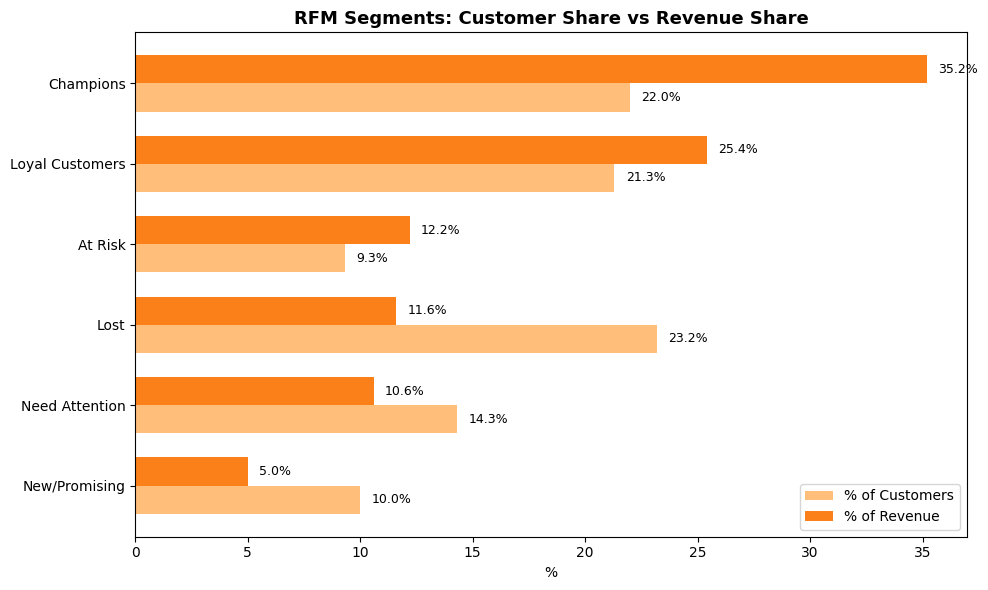

In [14]:
seg = seg_summary.sort_values('%_of_revenue', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(seg)); bar_height = 0.35

ax.barh(y - bar_height/2, seg['%_of_customers'], height=bar_height, label='% of Customers', color='#FFBE7A')
ax.barh(y + bar_height/2, seg['%_of_revenue'], height=bar_height, label='% of Revenue', color='#FC8019')
ax.set_yticks(y); ax.set_yticklabels(seg.index)
ax.set_xlabel('%'); ax.set_title('RFM Segments: Customer Share vs Revenue Share', fontsize=13, fontweight='bold')
ax.legend()

for i, (c, r) in enumerate(zip(seg['%_of_customers'], seg['%_of_revenue'])):
    ax.text(c + 0.5, i - bar_height/2, f'{c}%', va='center', fontsize=9)
    ax.text(r + 0.5, i + bar_height/2, f'{r}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('rfm_segments_chart.png', dpi=150, bbox_inches='tight')
plt.show()


**Key Insight:** Champions + Loyal Customers make up only ~43% of the user base but drive ~61% of total revenue. At-Risk customers (9.3% of users, 12.2% of revenue) represent the highest-value win-back opportunity.


## 5. Demographic Cuts

In [15]:
user_summary = user_orders.copy()
demo = users.merge(user_summary, on='user_id', how='left')
demo['order_count'] = demo['order_count'].fillna(0)
demo['total_spend'] = demo['total_spend'].fillna(0)
demo['has_ordered'] = demo['order_count'] > 0

for col in ['gender', 'occupation', 'marital_status']:
    summary = demo.groupby(col, observed=True).agg(
        users=('user_id','count'),
        conversion_rate=('has_ordered','mean'),
        avg_orders=('order_count','mean'),
        avg_spend=('total_spend','mean')
    ).round(2)
    summary['conversion_rate'] = (summary['conversion_rate']*100).round(1)
    print(f"--- By {col} ---")
    print(summary, "\n")


--- By gender ---
        users  conversion_rate  avg_orders  avg_spend
gender                                               
Female  42782             78.0         1.5    9986.51
Male    57218             78.0         1.5    9775.28 

--- By occupation ---
                users  conversion_rate  avg_orders  avg_spend
occupation                                                   
Employee        30408             78.0        1.51    9861.83
House wife       2322             77.0        1.49    9712.78
Self Employeed  13913             78.0        1.51    9802.18
Student         53357             78.0        1.50    9891.03 

--- By marital_status ---
                   users  conversion_rate  avg_orders  avg_spend
marital_status                                                  
Married            27831             78.0        1.51    9727.23
Prefer not to say   3092             77.0        1.52   11896.77
Single             69077             78.0        1.50    9830.50 



**Key Insight:** No meaningful variation in conversion rate or spend across age, gender, occupation, or marital status (~77-79% conversion across the board). This suggests engagement is driven by **behavioral** factors (captured in RFM) rather than demographic profile — retention strategy should focus on behavior-based targeting.


---
# PART B — Cookie Cats: A/B Test Analysis


## 6. Exploratory Analysis

In [16]:
cc = pd.read_csv('cookie_cats.csv')
print("Total players:", len(cc))
print(cc['version'].value_counts())
cc['sum_gamerounds'].describe()


Total players: 90189
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64


count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

## 7. Hypothesis Testing (Chi-Square)

In [17]:
ret1 = cc.groupby('version')['retention_1'].mean() * 100
ret7 = cc.groupby('version')['retention_7'].mean() * 100
print("Retention_1 % by group:\n", ret1.round(2))
print("\nRetention_7 % by group:\n", ret7.round(2))


Retention_1 % by group:
 version
gate_30    44.82
gate_40    44.23
Name: retention_1, dtype: float64

Retention_7 % by group:
 version
gate_30    19.02
gate_40    18.20
Name: retention_7, dtype: float64


In [18]:
ct1 = pd.crosstab(cc['version'], cc['retention_1'])
chi2_1, p1, dof1, exp1 = stats.chi2_contingency(ct1)
print(f"Retention_1: Chi2={chi2_1:.4f}, p-value={p1:.4f}",
      "-> Significant" if p1<0.05 else "-> NOT significant")

ct7 = pd.crosstab(cc['version'], cc['retention_7'])
chi2_7, p7, dof7, exp7 = stats.chi2_contingency(ct7)
print(f"Retention_7: Chi2={chi2_7:.4f}, p-value={p7:.4f}",
      "-> Significant" if p7<0.05 else "-> NOT significant")


Retention_1: Chi2=3.1591, p-value=0.0755 -> NOT significant
Retention_7: Chi2=9.9591, p-value=0.0016 -> Significant


In [19]:
summary = pd.DataFrame({
    'Metric': ['Retention_1', 'Retention_7'],
    'gate_30_%': [ret1['gate_30'], ret7['gate_30']],
    'gate_40_%': [ret1['gate_40'], ret7['gate_40']],
    'Difference_pp': [ret1['gate_30']-ret1['gate_40'], ret7['gate_30']-ret7['gate_40']],
    'p_value': [p1, p7],
    'Significant': [p1<0.05, p7<0.05]
})
summary.round(4)


,Metric,gate_30_%,gate_40_%,Difference_pp,p_value,Significant
0,Retention_1,44.8188,44.2283,0.5905,0.0755,False
1,Retention_7,19.0201,18.2000,0.8201,0.0016,True


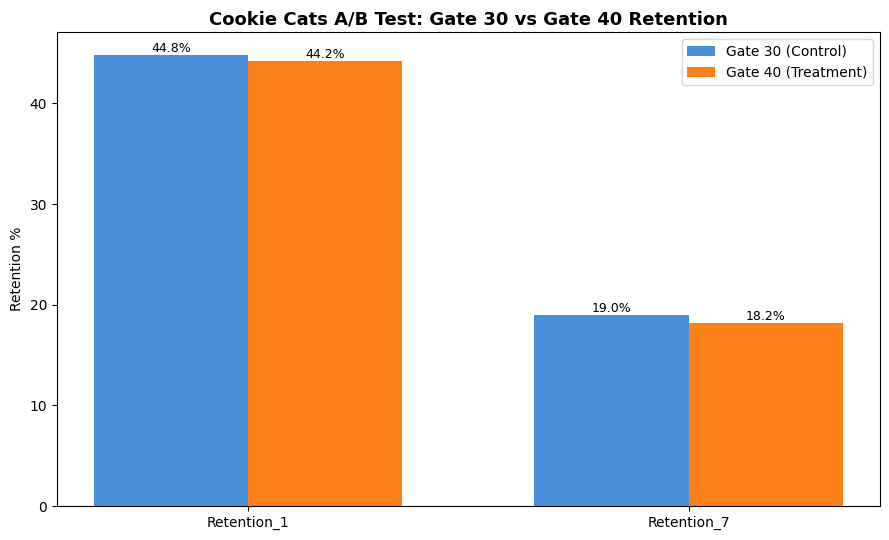

In [20]:
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(summary)); width = 0.35

bars1 = ax.bar(x - width/2, summary['gate_30_%'], width, label='Gate 30 (Control)', color='#4A90D9')
bars2 = ax.bar(x + width/2, summary['gate_40_%'], width, label='Gate 40 (Treatment)', color='#FC8019')

ax.set_xticks(x); ax.set_xticklabels(summary['Metric'])
ax.set_ylabel('Retention %')
ax.set_title('Cookie Cats A/B Test: Gate 30 vs Gate 40 Retention', fontsize=13, fontweight='bold')
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('ab_test_chart.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Business Recommendation

**Keep the gate at level 30 — do not move it to level 40.**

- Day-1 retention difference is small and **not statistically significant** (p=0.076)
- Day-7 retention is **significantly higher with Gate 30** (p=0.0016, below the 0.05 threshold)
- Moving the gate later (level 40) measurably **hurts long-term retention**, even though the short-term effect is inconclusive

**Recommendation: Reject the gate_40 treatment. Ship gate_30.**


---
# Summary of Findings

| Analysis | Key Finding |
|---|---|
| Funnel | 22.1% of users never convert; only 57.1% of buyers repeat |
| Retention | Month-1 retention averages ~4.4% — major re-engagement opportunity |
| RFM | Champions + Loyal (43% of users) drive 61% of revenue |
| Demographics | No significant variation — behavior matters more than profile |
| A/B Test | Gate 30 significantly outperforms Gate 40 on 7-day retention (p=0.0016) |

**Skills demonstrated:** Data Cleaning, Funnel Analysis, Cohort Analysis, RFM Segmentation, Statistical Hypothesis Testing (Chi-Square), Data Visualization, Business Recommendation Writing.
